<a href="https://colab.research.google.com/github/just-hw/GEN_HW1/blob/main/Hometasks/Base/GenDL_HT1_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

## Зачем это задание в нашем курсе про генеративные модели

Обучать генеративные модели интереснее всего — это понятно. Но сначала полезно один раз пройти весь пайплайн целиком: взять предобученную модель, измерить, где она ошибается, собрать данные под эту ошибку, дообучить, измерить снова. Этот цикл не зависит ни от задачи, ни от модальности — дальше в курсе вы будете крутить его же, только для изображений.

Задачу мы выбрали такую, где есть однозначная метрика. WER считается по эталонной расшифровке, и вы сразу видите, помогло ваше изменение или нет. В генерации картинок обратная связь честной уже не будет, поэтому тренируемся там, где она есть.

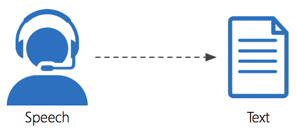

In [7]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

Скачиваем данные

In [6]:
!pip install ffmpeg-python

In [3]:
import requests
import pandas as pd
download_url = requests.get(
    "https://cloud-api.yandex.net/v1/disk/public/resources/download",
    params={"public_key": "https://disk.yandex.ru/d/v2Hipv7XG4fEDQ"}
).json()["href"]

In [4]:
df = pd.read_csv(download_url, sep="\t", header=None, names=["url"])
df

,url
0,http://storage.mds.yandex.net:80/get-voicetolo...
1,http://storage.mds.yandex.net:80/get-voicetolo...
2,http://storage.mds.yandex.net:80/get-voicetolo...
3,http://storage.mds.yandex.net:80/get-voicetolo...
4,http://storage.mds.yandex.net:80/get-voicetolo...
...,...
95,http://storage.mds.yandex.net:80/get-voicetolo...
96,http://storage.mds.yandex.net:80/get-voicetolo...
97,http://storage.mds.yandex.net:80/get-voicetolo...
98,http://storage.mds.yandex.net:80/get-voicetolo...


In [8]:
import ffmpeg
import os
import tqdm

os.makedirs(os.path.dirname('audio/'), exist_ok=True)

def download_audio(url, output_path):
    url = str(url).strip()

    try:
        (
            ffmpeg
            .input(url)
            .output(
                output_path,
                ar=16000,
                ac=1,
                acodec="pcm_s16le"
            )
            .overwrite_output()
            .run(
                capture_stdout=True,
                capture_stderr=True
            )
        )

    except ffmpeg.Error as e:
        print(e.stderr.decode("utf-8", errors="replace"))
        raise

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
for i, url in enumerate(tqdm.tqdm(df["url"])):
    output_path = f"audio/{i:03d}.wav"

    if os.path.exists(output_path):
        continue
    download_audio(url, output_path)

100%|██████████| 100/100 [03:55<00:00,  2.35s/it]


In [48]:
#!cp -r /content/audio /content/drive/MyDrive/audio

# сохраняю аудио на диск чтобы не скачивать каждый раз при переподключении ноутбука

Применяем whisper-small

In [10]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch
import torchaudio
# также вам может пригодиться установить распознавание русского языка как гиперпараметр whisper-small, так как наш датасет русскоязычный

In [32]:
# !pip install -U transformers accelerate datasets[audio]

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"
).to(device)

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="russian",
    task="transcribe"
)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

In [12]:
def transcribe(path):
    audio, sr = torchaudio.load(path)

    audio = audio.mean(dim=0)

    if sr != 16000:
        audio = torchaudio.functional.resample(audio, sr, 16000)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_features = inputs.input_features.to(device)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )

    return processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0].strip()

In [57]:
results = []

for i in tqdm.tqdm(range(len(df))):
    path = f"drive/MyDrive/audio/{i:03d}.wav"

    try:
        text = transcribe(path)

        results.append({
            "id": i,
            "url": df.iloc[i]["url"],
            "transcription": text
        })

    except Exception as e:
        results.append({
            "id": i,
            "url": df.iloc[i]["url"],
            "transcription": None
        })

        print(f"Ошибка {i}: {e}")

100%|██████████| 100/100 [00:37<00:00,  2.67it/s]


In [94]:
df_transcriptions = pd.DataFrame(results).drop(columns=['id'])
sample = df_transcriptions.sample(10, random_state=89)
sample

,url,transcription
65,http://storage.mds.yandex.net:80/get-voicetolo...,Ханс Хартун
21,http://storage.mds.yandex.net:80/get-voicetolo...,Крошенинников Степан Петрович
87,http://storage.mds.yandex.net:80/get-voicetolo...,Франциска Писсера
6,http://storage.mds.yandex.net:80/get-voicetolo...,Ralf finds.
46,http://storage.mds.yandex.net:80/get-voicetolo...,город бога
74,http://storage.mds.yandex.net:80/get-voicetolo...,Космическая Одессия 2001 года
44,http://storage.mds.yandex.net:80/get-voicetolo...,"Барьмонт, Костянкин Дмитрий."
60,http://storage.mds.yandex.net:80/get-voicetolo...,Зег мунд фрейд
72,http://storage.mds.yandex.net:80/get-voicetolo...,Ходосевич Владислав Филицанович
5,http://storage.mds.yandex.net:80/get-voicetolo...,Дневник памяти.


## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [27]:
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast

sc_tokenizer = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")
sc_model = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell")
MAX_INPUT = 512

tokenizer_config.json:   0%|          | 0.00/1.94k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B / 1.00MB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.63M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [33]:
input_sequences = sample['transcription'].tolist()
encoded = sc_tokenizer(
  input_sequences,
  padding="longest",
  max_length=MAX_INPUT,
  truncation=True,
  return_tensors="pt",
)
predicts = sc_model.generate(**encoded)
sample_sc = sc_tokenizer.batch_decode(predicts, skip_special_tokens=True)  # Декодируем данные


In [59]:
pd.DataFrame({"before spell correction": input_sequences,
              "after spell correction": sample_sc})

,before spell correction,after spell correction
0,Помни!,"Помни, Помни."
1,Гроздь я к Неву.,Гроздь я к Неву.
2,Мой сосед татура.,Мой сосед Татура.
3,Джон Гудман,Джон Гудман
4,Побег из Шаушенко,Побег из Шаушенко
5,Космическая Одессия 2001 года,"Космическая Одесса, 2001 года"
6,Огни большого города,Огни большого города
7,Голова ломка.,Голова ломка.
8,Смоки Робинсон,Смоки Робинсон
9,Новый кинотеатр пародизо,Новый кинотеатр пародии


## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

### Подсказка (промт-бейзлайн)

Вам нужно придумать хороший промпт для модели, чтобы подсобрать обучающих данных.

Начать можно с этого:

```
examples_per_request = 10

asr_prompt = f"""Сгенерируй {examples_per_request} примеров исправления ошибок
распознавания речи на русском языке.

Верни JSON:
[{{"input": "текст с ошибками", "output": "исправленный текст"}}]
"""
```

Соберите этим промптом штук 30 примеров и посмотрите на них глазами. Скорее всего, вы заметите часть из следующего:

- предложения повторяются от запроса к запросу, а тематика однообразная и неподходящая
- ошибки не похожи на то, что реально выдал whisper на шаге 1 — сравните с его расшифровками
- в выборке нет ни одного примера, где исправлять нечего (input == output)
часть ответов не парсится, потому что модель дописала пояснение до или после JSON
- длина предложений скачет от двух слов до абзаца

Каждый из этих пунктов — направление для правки промпта. Подумайте:

- что модель должна знать про задачу, чтобы генерировать релевантные ошибки, и как ей это сообщить
- какие типы ошибок ASR вы видели на шаге 1 и стоит ли перечислить их явно
- как заставить модель не писать ничего, кроме JSON
- как добиться разнообразия между запросами, если промпт каждый раз один и тот же
- что произойдёт с дообученной моделью, если в данных нет ни одного корректного предложения

Правьте промпт по одному изменению за раз и смотрите, что поменялось в выдаче. Перед сохранением датасета не забудьте убрать дубликаты — их будет больше, чем кажется.


In [67]:
# %env GROQ_API_KEY=key

In [73]:
!pip install groq

#### I. Попробуем обычный промпт

In [71]:
examples_per_request = 30

system_prompt = f"""Сгенерируй {examples_per_request} примеров исправления ошибок
распознавания речи на русском языке.

Верни JSON:
[{{"input": "текст с ошибками", "output": "исправленный текст"}}]
"""

In [72]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="openai/gpt-oss-20b", # можно брать и другие доступные у groq модели
)

print(response.choices[0].message.content)

```json
[
  {"input":"я иду в мажакин","output":"я иду в магазин"},
  {"input":"пожалуйста, послушайте мэо","output":"пожалуйста, послушайте меня"},
  {"input":"он сказал, что будет завтра","output":"он сказал, что будет завтра"},
  {"input":"я купил яблоко, но не яблоко","output":"я купил яблоко, но не груша"},
  {"input":"сегодня погода хорошая и солнечная","output":"сегодня погода хорошая и солнечная"},
  {"input":"привет, как дела, как дела?","output":"привет, как дела?"},
  {"input":"я люблю кататься на коньках","output":"я люблю кататься на коньках"},
  {"input":"у меня есть 5 яблок","output":"у меня есть пять яблок"},
  {"input":"пойду домой после работы","output":"пойду домой после работы"},
  {"input":"вы хотите кофе или чай?","output":"вы хотите кофе или чай?"},
  {"input":"на улице дождь и холодно","output":"на улице дождь и холодно"},
  {"input":"это хороший фильм, но он был длинный","output":"это хороший фильм, но он был длинный"},
  {"input":"я работаю в банке, а не в маг

Для этого промпта существуют следующие проблемы (в контексте нашего задания):
1) ошибки не похожи на то, что реально выдал whisper
2) некоторые исправления неправлильные (заменяет "яблоко" на "груша")
3) после 10 примера начинает выдавать одинаковые строки в input и в output


Попробуем доработать промпт, зная эти проблемы

- что модель должна знать про задачу, чтобы генерировать релевантные ошибки, и как ей это сообщить
- какие типы ошибок ASR вы видели на шаге 1 и стоит ли перечислить их явно
- как заставить модель не писать ничего, кроме JSON
- как добиться разнообразия между запросами, если промпт каждый раз один и тот же
- что произойдёт с дообученной моделью, если в данных нет ни одного корректного предложения


In [89]:
# для начала добавим контекст, чтобы модель понимала задачу лучше
examples_per_request = 10

system_prompt = f"""Сгенерируй {examples_per_request} примеров исправления ошибок
распознавания речи на русском языке.
Примеры должны быть связаны с миром кинематографа. То есть запросы, которые люди
ищут на киноаггрегаторе (Кинопоиск, letterboxd). Например это могут быть имена
голливудских актеров/режиссеров/сценаристов и т.д. или названия культовых фильмов
и сериалов. Также это может быть что-либо связанное с культурой -
известные музыканты/художники и видные деятели культуры.

Верни JSON:
[{{"input": "текст с ошибками", "output": "исправленный текст"}}]
"""

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="openai/gpt-oss-20b", # qwen/qwen3.8-27b можно попробовать,
    reasoning_effort="low" # поставим ризонинг меньше
)

print(response.choices[0].message.content)

```json
[
  {
    "input": "выпиши название фильма о пицце, где главный герой по имени Патрик и режиссер Стивен Спилберг",
    "output": "выпиши название фильма о пицце, где главный герой по имени Патрик, а режиссер Стивен Спилберг"
  },
  {
    "input": "кто из актёров сыграл в фильме «Интерстеллар»? Я помню Киллиана Мёрфи",
    "output": "кто из актёров сыграл в фильме «Интерстеллар»? Я помню Киллиана Мёрфи"
  },
  {
    "input": "покажи мне все фильмы где актриса Андра́с Ку́рвиль исполняет роль главной героини",
    "output": "покажи мне все фильмы, где актриса Андрэй Куравиль исполняет роль главной героини"
  },
  {
    "input": "сериал о супергероях называется «Пасифы»",
    "output": "сериал о супергероях называется «Пасифы»"
  },
  {
    "input": "найди фильм про супермена 1987 года с Джейсоном Джейкобсом",
    "output": "найди фильм про Супермена 1987 года с Джейсоном Джейкобсом"
  },
  {
    "input": "какой режиссёр сделал «Победу в битве за Землю» в 2010",
    "output": "како

Модель сильно тупит и выводит данные совсем не в том формате, который нам нужен, попробуем учесть все ошибки прошлого и поменять модель

In [93]:
# добавим пример вывода, который мы ожидаем
system_prompt = """Сгенерируй 10 примеров исправления ошибок
распознавания речи на русском языке.
Примеры должны быть связаны с миром кинематографа. То есть запросы, которые люди
ищут на киноаггрегаторе (Кинопоиск, letterboxd). Например это могут быть имена
голливудских актеров/режиссеров/сценаристов и т.д. или названия культовых фильмов
и сериалов. Также это может быть что-либо связанное с культурой -
известные музыканты/художники и видные деятели культуры.

Верни JSON без Markdown, пояснений и дополнительного текста:
[{"input": "текст с ошибками", "output": "исправленный текст"}]

Пример вывода:
[
  {"input": "Помни!", "output": "Помни!"},
  {"input": "Гроздь я к Неву", "output": "Гроздья гнева"},
  {"input": "Мой сосед татура", "output": "Мой сосед Тоторо"},
  {"input": "Зег мунд фрейд", "output": "Зигмунд Фрейд"},
  {"input": "Побег из Шаушенко", "output": "Побег из Шоушенка"},
  {"input": "Космическая Одессия 2001", "output": "Космическая Одиссея 2001"},
  {"input": "Окна большого города", "output": "Огни большого города"},
  {"input": "Голова ломка", "output": "Головоломка"},
  {"input": "Смок и Робинс", "output": "Смоки Робинсон"},
  {"input": "Новый кинотеатр пародии", "output": "Новый кинотеатр Парадизо"}
]
"""

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="qwen/qwen3.8-27b", # qwen/qwen3.8-27b можно попробовать,
    # reasoning_effort="low" # поставим ризонинг меньше
)

print(response.choices[0].message.content)

[
  {"input": "Леонардо Ди Каприо", "output": "Леонардо Ди Каприо"},
  {"input": "Скроббиз и Гриффины", "output": "Скраббл"},
  {"input": "Ричард Гир", "output": "Ричард Гир"},
  {"input": "Интерстелер", "output": "Интерстеллар"},
  {"input": "Кристофер Нолан", "output": "Кристофер Нолан"},
  {"input": "Виктор Франкенштейн", "output": "Франкенштейн"},
  {"input": "Дэнни Боил", "output": "Дэнни Бойл"},
  {"input": "Матрица", "output": "Матрица"},
  {"input": "Шакер", "output": "Шрек"},
  {"input": "Кэмерон Диас", "output": "Кэмерон Диас"}
]


In [99]:
# перечислим все ошибки, которые модель должна избегать
# а также уточним специфику нашей задачи
system_prompt = """Сгенерируй 10 примеров исправления ошибок
распознавания речи на русском языке.
Наша цель - улучшить систему транскрибации аудиозаписей запросов пользователей.
Например, пользователь говорит "Пьер Ришар", но в транскрибации распознается "Пил и
шар". Цель - исправить ошибку ASR и улушчить точность системы автокоррекции.
То есть из "Пил и шар" мы должны сделать "Пьер Ришар".

Примеры должны быть связаны с миром кинематографа. То есть запросы, которые люди
ищут на киноаггрегаторе (Кинопоиск, letterboxd). Например это могут быть имена
голливудских актеров/режиссеров/сценаристов и т.д. или названия культовых фильмов
и сериалов. Также это может быть что-либо связанное с культурой -
известные музыканты/художники и видные деятели культуры.

ПРАВИЛА ПРИ ГЕНЕРАЦИИ:
1) Количество примеров где input==output должно составлять примерно 20% от всех
примеров. То есть Каждый ПЯТЫЙ пример должен быть таким, в котором исправления не
нужны, НО НЕ ЧАЩЕ!!!
2) НЕЛЬЗЯ допускать примеры где на выходе пропадает осмысленное слово. Например,
"Виктор Франкенштейн" нельзя исправлять на "Франкенштейн", потому что это разные
запросы! Количество слов на входе и выходе может отличаться, если несколько слов
можно склеить в одно слово.
3) НЕЛЬЗЯ генерировать примеры, где полностью меняется смысл слова, несмотря на
то что на входе оно было логично встроено в предложение. Например, нельзя менять
"Вкус жизни" на "Вкус живота".
4) НЕЛЬЗЯ придумывать несуществующих личностей/фильмы/литературу и тд. Просто используй
различные примеры из РЕАЛЬНОГО МИРА. То на чем люди ДЕЙСТВИТЕЛЬНО делают ошибки.

Верни JSON без Markdown, пояснений и дополнительного текста:
[{"input": "текст с ошибками", "output": "исправленный текст"}]

Пример вывода:
[
  {"input": "Помни!", "output": "Помни!"},
  {"input": "Гроздь я к Неву", "output": "Гроздья гнева"},
  {"input": "Мой сосед татура", "output": "Мой сосед Тоторо"},
  {"input": "Зег мунд фрейд", "output": "Зигмунд Фрейд"},
  {"input": "Побег из Шаушенко", "output": "Побег из Шоушенка"},
  {"input": "Космическая Одессия 2001", "output": "Космическая Одиссея 2001"},
  {"input": "Окна большого города", "output": "Огни большого города"},
  {"input": "Голова ломка", "output": "Головоломка"},
  {"input": "Смок и Робинс", "output": "Смоки Робинсон"},
  {"input": "Новый кинотеатр пародии", "output": "Новый кинотеатр Парадизо"}
]
"""

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="openai/gpt-oss-20b", # qwen/qwen3.8-27b можно попробовать,
    # reasoning_effort="low" # поставим ризонинг меньше
)

print(response.choices[0].message.content)

[
  {"input": "Пол Пондэр", "output": "Поль Пондер"},
  {"input": "Гари Потер", "output": "Гарри Поттер"},
  {"input": "Том Ханкс", "output": "Том Хэнкс"},
  {"input": "Логон", "output": "Логан"},
  {"input": "Стар Трек", "output": "Стар Трек"},
  {"input": "Пираты Карибского мор", "output": "Пираты Карибского моря"},
  {"input": "Трансформерс", "output": "Трансформеры"},
  {"input": "Властелин кольцо", "output": "Властелин колец"},
  {"input": "Майор Джон Кенни", "output": "Майор Джон Кеннеди"},
  {"input": "Форсаж", "output": "Форсаж"}
]


In [100]:
import json
response_text = response.choices[0].message.content
data = json.loads(response_text)
df = pd.DataFrame(data)
df

,input,output
0,Пол Пондэр,Поль Пондер
1,Гари Потер,Гарри Поттер
2,Том Ханкс,Том Хэнкс
3,Логон,Логан
4,Стар Трек,Стар Трек
5,Пираты Карибского мор,Пираты Карибского моря
6,Трансформерс,Трансформеры
7,Властелин кольцо,Властелин колец
8,Майор Джон Кенни,Майор Джон Кеннеди
9,Форсаж,Форсаж


Нам удалось соорудить неплохой промпт, теперь можно проверить способность генерации датасета из 1000+ строк.

In [101]:
system_prompt = """Сгенерируй 1500 примеров исправления ошибок
распознавания речи на русском языке.
Наша цель - улучшить систему транскрибации аудиозаписей запросов пользователей.
Например, пользователь говорит "Пьер Ришар", но в транскрибации распознается "Пил и
шар". Цель - исправить ошибку ASR и улушчить точность системы автокоррекции.
То есть из "Пил и шар" мы должны сделать "Пьер Ришар".

Примеры должны быть связаны с миром кинематографа. То есть запросы, которые люди
ищут на киноаггрегаторе (Кинопоиск, letterboxd). Например это могут быть имена
голливудских актеров/режиссеров/сценаристов и т.д. или названия культовых фильмов
и сериалов. Также это может быть что-либо связанное с культурой -
известные музыканты/художники и видные деятели культуры.

ПРАВИЛА ПРИ ГЕНЕРАЦИИ:
1) Количество примеров где input==output должно составлять примерно 20% от всех
примеров. То есть Каждый ПЯТЫЙ пример должен быть таким, в котором исправления не
нужны, НО НЕ ЧАЩЕ!!!
2) НЕЛЬЗЯ допускать примеры где на выходе пропадает осмысленное слово. Например,
"Виктор Франкенштейн" нельзя исправлять на "Франкенштейн", потому что это разные
запросы! Количество слов на входе и выходе может отличаться, если несколько слов
можно склеить в одно слово.
3) НЕЛЬЗЯ генерировать примеры, где полностью меняется смысл слова, несмотря на
то что на входе оно было логично встроено в предложение. Например, нельзя менять
"Вкус жизни" на "Вкус живота".
4) НЕЛЬЗЯ придумывать несуществующих личностей/фильмы/литературу и тд. Просто используй
различные примеры из РЕАЛЬНОГО МИРА. То на чем люди ДЕЙСТВИТЕЛЬНО делают ошибки.

Верни JSON без Markdown, пояснений и дополнительного текста:
[{"input": "текст с ошибками", "output": "исправленный текст"}]

Пример вывода:
[
  {"input": "Помни!", "output": "Помни!"},
  {"input": "Гроздь я к Неву", "output": "Гроздья гнева"},
  {"input": "Мой сосед татура", "output": "Мой сосед Тоторо"},
  {"input": "Зег мунд фрейд", "output": "Зигмунд Фрейд"},
  {"input": "Побег из Шаушенко", "output": "Побег из Шоушенка"},
  {"input": "Космическая Одессия 2001", "output": "Космическая Одиссея 2001"},
  {"input": "Окна большого города", "output": "Огни большого города"},
  {"input": "Голова ломка", "output": "Головоломка"},
  {"input": "Смок и Робинс", "output": "Смоки Робинсон"},
  {"input": "Новый кинотеатр пародии", "output": "Новый кинотеатр Парадизо"}
]
"""

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="openai/gpt-oss-20b",
    # reasoning_effort="low" # поставим ризонинг меньше
)

print(response.choices[0].message.content)

In [102]:
response.choices[0]

Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning='We need 1500 examples of input-output pairs. 20% should be correct (no change). So 300 pairs unchanged. 1200 pairs with corrections. Must be realistic ASR errors: misrecognition of names, films, etc. Must not remove words; keep same number of meaningful words. Should be plausible errors: homophones, misheard letters. Also ensure we don\'t invent non-existent persons. Use real cinema-related names. We\'ll produce JSON array of 1500 objects. This is large. We need to output 1500 JSON entries. That is huge; but maybe the expectation is to produce 1500. It\'s large but doable. We need to ensure each 5th example is correct. So sequence: 1-4 corrected, 5 correct. Repeat. So we can programmatically generate pattern.\n\nWe should produce variety: actors, directors, film titles. Must reflect realistic ASR errors:

In [ ]:
# кажется, просить у модели выход размером 1500 строк это перебор
# попробуем оптимизировать систему так, чтобы модель выводила за 100 строк за
# раз, но при этом не повторялась. Для этого добавим специальный префикс в
# котором будут взаимоисключающие правила генерации, например первые буквы.
prefix = f"""Сгенерируй 100 примеров исправления ошибок
распознавания речи на русском языке. Все примеры должны начинаться на буквы:
{letters}"""
system_prompt = """Наша цель - улучшить систему транскрибации аудиозаписей запросов пользователей.
Например, пользователь говорит "Пьер Ришар", но в транскрибации распознается "Пил и
шар". Цель - исправить ошибку ASR и улушчить точность системы автокоррекции.
То есть из "Пил и шар" мы должны сделать "Пьер Ришар".

Примеры должны быть связаны с миром кинематографа. То есть запросы, которые люди
ищут на киноаггрегаторе (Кинопоиск, letterboxd). Например это могут быть имена
голливудских актеров/режиссеров/сценаристов и т.д. или названия культовых фильмов
и сериалов. Также это может быть что-либо связанное с культурой -
известные музыканты/художники и видные деятели культуры.

ПРАВИЛА ПРИ ГЕНЕРАЦИИ:
1) Количество примеров где input==output должно составлять примерно 20% от всех
примеров. То есть Каждый ПЯТЫЙ пример должен быть таким, в котором исправления не
нужны, НО НЕ ЧАЩЕ!!!
2) НЕЛЬЗЯ допускать примеры где на выходе пропадает осмысленное слово. Например,
"Виктор Франкенштейн" нельзя исправлять на "Франкенштейн", потому что это разные
запросы! Количество слов на входе и выходе может отличаться, если несколько слов
можно склеить в одно слово.
3) НЕЛЬЗЯ генерировать примеры, где полностью меняется смысл слова, несмотря на
то что на входе оно было логично встроено в предложение. Например, нельзя менять
"Вкус жизни" на "Вкус живота".
4) НЕЛЬЗЯ придумывать несуществующих личностей/фильмы/литературу и тд. Просто используй
различные примеры из РЕАЛЬНОГО МИРА. То на чем люди ДЕЙСТВИТЕЛЬНО делают ошибки.
5) НЕЛЬЗЯ писать скрипт для генерации этих примеров! Нужны просто сами примеры.

Верни JSON без Markdown, пояснений и дополнительного текста:
[{"input": "текст с ошибками", "output": "исправленный текст"}]

Пример вывода:
[
  {"input": "Помни!", "output": "Помни!"},
  {"input": "Гроздь я к Неву", "output": "Гроздья гнева"},
  {"input": "Мой сосед татура", "output": "Мой сосед Тоторо"},
  {"input": "Зег мунд фрейд", "output": "Зигмунд Фрейд"},
  {"input": "Побег из Шаушенко", "output": "Побег из Шоушенка"},
  {"input": "Космическая Одессия 2001", "output": "Космическая Одиссея 2001"},
  {"input": "Окна большого города", "output": "Огни большого города"},
  {"input": "Голова ломка", "output": "Головоломка"},
  {"input": "Смок и Робинс", "output": "Смоки Робинсон"},
  {"input": "Новый кинотеатр пародии", "output": "Новый кинотеатр Парадизо"}
]
"""

alphabet_groups = [
    "а, б",
    "в, г",
    "д, е",
    "ё, ж",
    "з, и",
    "й, к",
    "л, м",
    "н, о",
    "п, р",
    "с, т",
    "у, ф",
    "х, ц",
    "ч, ш, щ",
    "ъ, ы, ь",
    "э, ю, я"
]

response = client.chat.completions.create(
    messages=[{"role": "user", "content": system_prompt}],
    model="openai/gpt-oss-20b",
    # reasoning_effort="low" # поставим ризонинг меньше
)

print(response.choices[0].message.content)

In [ ]:
data = []
for i in aplhabet_groups:


In [ ]:
# Сохраните собранный датасет в файл и прикрепите сюда ссылку на него

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
!pip install --upgrade transformers datasets

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

# Модель
...

# Загружаем свой CSV с парами (input → target)
...

# Токенизация
...

# Data collator
...

# Аргументы обучения
training_args = Seq2SeqTrainingArguments(...)

# Trainer
trainer = Seq2SeqTrainer(...)

# Запускаем обучение
trainer.train()

# Сохраняем дообученную модель
trainer.save_model("...")
tokenizer.save_pretrained("...")

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загружаем дообученную модель
model_path = "..."
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Применение модели к 10 примерам
...

## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [ ]:
# ваш код здесь

## Шаг 6 (2.5 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [ ]:
# ваши эксперименты здесь

## Дополнение к шагу 1: декодирование и его артефакты (0.5 балла)

Эти два эксперимента — про саму модель whisper-small «как есть», без spell-correction и без дообучения (они будут в следующих шагах). Здесь нас интересует не качество распознавания само по себе, а то, как устроена генерация токен за токеном.

**а) Стратегия декодирования (0.25 балла)**

Декодер whisper-small — авторегрессионный трансформер: он порождает расшифровку токен за токеном, ровно тем же механизмом, что и языковые модели с лекции. Только префикс здесь не текстовый, а представление аудио. При этом то, какой токен окажется выбран на каждом шаге, определяется не только весами модели, но и стратегией декодирования.

Сравните на одной и той же выборке аудио несколько режимов генерации и посчитайте WER для каждого (эталонные расшифровки — тот же файл с ответами, что и в шаге 5; здесь мы просто используем его раньше по ходу задания):

- жадное декодирование: num_beams=1, do_sample=False
- лучевой поиск: num_beams=5 (попробуйте и другие значения)
- сэмплирование с температурой: do_sample=True и temperature из, например, [0.2, 0.7, 1.0]

Все эти параметры передаются в model.generate(...).

Сделайте выводы:

- какой режим дал наименьший WER и почему
что происходит с качеством при росте температуры
почему для распознавания речи температура ведёт себя не так, как для свободной генерации текста, где разнообразие ответа часто является плюсом

**б) Галлюцинации модели (0.25 балла)**

Whisper известен тем, что на тишине, шуме или музыке без речи уверенно выдаёт связный и грамматически правильный, но полностью выдуманный текст.

Найдите в датасете хотя бы один такой пример — либо сконструируйте его сами, подав на вход несколько секунд тишины или шума

Приведите расшифровку, которую выдала модель

Объясните, почему авторегрессионная модель в этой ситуации порождает правдоподобный текст, а не отказывается отвечать. Что именно она оптимизирует на каждом шаге генерации?
Предложите способ отлавливать такие случаи автоматически.

In [ ]:
# (а): сравнение стратегий декодирования
# Прогоните одну и ту же выборку аудио через несколько наборов параметров generate
# и посчитайте WER для каждого набора.

# decoding_configs = {
#     "greedy":      dict(num_beams=1, do_sample=False),
#     "beam_5":      dict(num_beams=5, do_sample=False),
#     "sample_t0.2": dict(do_sample=True, temperature=0.2),
#     "sample_t0.7": dict(do_sample=True, temperature=0.7),
#     "sample_t1.0": dict(do_sample=True, temperature=1.0),
# }

# ваш код здесь


#(б): галлюцинации на тишине/шуме
# Подсказка для конструирования примера:
# silence = torch.zeros(1, 16000 * 5)          # 5 секунд тишины
# noise   = torch.randn(1, 16000 * 5) * 0.01   # 5 секунд слабого шума

# ваш код здесь
